# Lab 03: Computer Vision Prototyping & Object Detection Pipeline
**Course:** AI Project Design and Development  
**Application areas:** traffic monitoring, industrial inspection, medical image processing, retail inventory, and security.

Tasks 1–6 run in this notebook. Tasks 7–8 are executable webcam scripts described at the end. Use the existing `aipdd_env` Python environment as the notebook kernel and run all cells in order. Paths work when Jupyter starts in either the repository root or `notebooks/`.

## Required input images
The five public sample images below have been downloaded into these exact repository-relative paths. They are real source photographs; the notebook does not fabricate or download input images. Replace them with your own images if desired.

| Path | Required content | Used by |
| --- | --- | --- |
| `data/raw/traffic_scene.jpg` | High-resolution road scene with vehicles, preferably at least 1280 x 720 | Tasks 1 and 4 |
| `data/raw/industrial_product.jpg` | Product surface with a visible red mark or red defect candidate | Task 2 |
| `data/raw/medical_scan.png` | De-identified medical scan suitable for grayscale edge analysis | Task 3 |
| `data/raw/retail_shelf.jpg` | Shelf containing visible bottles (or apples after changing TARGET_CLASS) | Task 5 |
| `data/raw/surveillance_scene.jpg` | Surveillance view with people and a meaningful restricted area | Task 6 |

Missing or unreadable inputs produce a useful skip message. Add the files and rerun all cells to generate the submission figures and tables. Task folders are created only when results are saved. Pretrained `yolov8n.pt` and `yolov8m.pt` weights download automatically into `models/` on first use; internet access is needed for that first run. Model loading is deferred until an input image exists.

## Sample Image Sources and Attribution
Downloaded for this lab on 2026-10-06 from Wikimedia Commons. Original image bytes are preserved for the first four files. The pedestrian image uses Wikimedia's 1280-pixel-wide thumbnail to keep the sample compact. All five files use the required local filenames; no synthetic content was added. Source authors and licenses remain applicable to the images and their derived visualizations.

| Local file in `data/raw/` | Source and author | License | Use in this lab |
| --- | --- | --- | --- |
| `traffic_scene.jpg` | [Trafficjam.jpg](https://commons.wikimedia.org/wiki/File:Trafficjam.jpg), U.S. Census Bureau | [Public domain: U.S. government work](https://commons.wikimedia.org/wiki/Template:PD-USGov-Census) | Road traffic preprocessing and detection benchmark |
| `industrial_product.jpg` | [Rust on metal.jpg](https://commons.wikimedia.org/wiki/File:Rust_on_metal.jpg), Georges Grondin | [Public-domain release](https://commons.wikimedia.org/wiki/File:Rust_on_metal.jpg#Licensing) | Red/brown corrosion candidate segmentation on a real metal surface |
| `medical_scan.png` | [Chest.png](https://commons.wikimedia.org/wiki/File:Chest.png), Chikumaya | [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/) | Public chest X-ray with no patient identifiers visible in the image; grayscale edge comparison |
| `retail_shelf.jpg` | [Soda bottle shelf.jpg](https://commons.wikimedia.org/wiki/File:Soda_bottle_shelf.jpg), Anselm Schüler | [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) | Supermarket bottle detection and counting |
| `surveillance_scene.jpg` | [Pedestrians crossing the street in Barcelona DSF0993.jpg](https://commons.wikimedia.org/wiki/File:Pedestrians_crossing_the_street_in_Barcelona_DSF0993.jpg), Levi Meir Clancy | [CC0 1.0](https://creativecommons.org/publicdomain/zero/1.0/) | Public pedestrian street photograph used as a surveillance-style ROI demonstration; not recorded CCTV footage |

Derived outputs apply resizing, color conversion, masking, edge extraction, or detection overlays as described in each task. Task 3 image derivatives are shared under CC BY-SA 3.0; Task 5 image derivatives are shared under CC BY-SA 4.0. These licenses apply to those image derivatives, not automatically to unrelated code. Raw inputs have no annotations added. Detection counts are model predictions, not manually verified inventories.

In [1]:
from pathlib import Path
import os

# Locate this repository without depending on an absolute machine-specific path.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "requirements.txt").is_file() or not (ROOT / "src").is_dir():
    raise RuntimeError("Start this notebook from the repository root or notebooks folder.")

# Keep runtime configuration within the existing ignored environment directory.
CACHE = ROOT / "aipdd_env" / "lab03_cache"
for variable, folder in (("MPLCONFIGDIR", "matplotlib"), ("YOLO_CONFIG_DIR", "ultralytics")):
    directory = CACHE / folder
    directory.mkdir(parents=True, exist_ok=True)
    os.environ[variable] = str(directory)

import csv
import json
from collections import Counter
from statistics import mean
from time import perf_counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from ultralytics import YOLO

DATA = ROOT / "data" / "raw"
OUTPUT = ROOT / "outputs" / "lab03"
DEVICE = "cpu"  # Same explicit device for both benchmark models.
STATUS = {}
MODELS = {}
plt.rcParams["figure.dpi"] = 110
print(f"Repository: {ROOT.name}")
print(f"OpenCV: {cv2.__version__}; PyTorch: {torch.__version__}; device: {DEVICE}")

Repository: Ai-Project-Design-Development
OpenCV: 5.0.0; PyTorch: 2.8.0+cpu; device: cpu


## Shared helpers
OpenCV loads BGR pixels; plots use RGB. Saved figures and CSV/JSON tables preserve submission evidence. Inference boxes use original-image pixel coordinates returned by Ultralytics. The model's own preprocessing is used for Tasks 4–6; Task 1 independently demonstrates letterboxing and normalization.

In [2]:
def load_image(filename, task, grayscale=False):
    """Read an available image or mark the task skipped with an actionable message."""
    path = DATA / filename
    if not path.is_file():
        STATUS[task] = "Skipped: missing input"
        print(f"Task {task} skipped: add {path.relative_to(ROOT).as_posix()} and rerun.")
        return None
    mode = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    image = cv2.imread(str(path), mode)
    if image is None:
        STATUS[task] = "Skipped: unreadable input"
        print(f"Task {task} skipped: OpenCV could not read {path.relative_to(ROOT)}. Replace it with a valid image.")
    return image


def output_path(task, filename):
    directory = OUTPUT / f"task{task}"
    directory.mkdir(parents=True, exist_ok=True)
    return directory / filename


def save_figure(task, filename, figure):
    figure.savefig(output_path(task, filename), bbox_inches="tight")
    plt.show()
    plt.close(figure)


def save_image(task, filename, image):
    path = output_path(task, filename)
    if not cv2.imwrite(str(path), image):
        raise OSError(f"Could not save {path}")


def show_table(rows):
    headers = list(rows[0])
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(str(row[key]) for key in headers) + " |" for row in rows]
    display(Markdown("\n".join(lines)))


def save_csv(task, filename, rows):
    with output_path(task, filename).open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def get_model(name):
    if name not in MODELS:
        weights = ROOT / "models" / name
        weights.parent.mkdir(parents=True, exist_ok=True)
        MODELS[name] = YOLO(str(weights))
    return MODELS[name]


def detections_from(result):
    rows = []
    for box in result.boxes:
        class_id = int(box.cls.item())
        rows.append({"class_id": class_id, "label": result.names[class_id],
                     "confidence": float(box.conf.item()),
                     "box": [float(value) for value in box.xyxy[0].cpu().tolist()]})
    return rows


def draw_boxes(image, detections, color=(0, 200, 255)):
    output = image.copy()
    scale = max(1.0, image.shape[1] / 1200)
    thickness = max(2, round(2 * scale))
    for item in detections:
        x1, y1, x2, y2 = map(int, item["box"])
        cv2.rectangle(output, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(output, f"{item['label']} {item['confidence']:.2f}",
                    (x1, max(round(24 * scale), y1 - round(8 * scale))),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7 * scale, color, thickness)
    return output


def banner(image, message, color=(0, 255, 0)):
    output = image.copy()
    scale = max(1.0, image.shape[1] / 1200)
    cv2.rectangle(output, (0, 0), (output.shape[1], round(50 * scale)), (25, 25, 25), -1)
    cv2.putText(output, message, (round(10 * scale), round(33 * scale)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8 * scale, color, max(2, round(2 * scale)))
    return output

## Task 1 — Automated Preprocessing Pipeline
**Application: Traffic Monitoring & Vehicle Counting.** Preserve the road scene's aspect ratio by resizing proportionally and padding to 640 × 640. Convert to RGB float32 in [0, 1] and compare the original and model-ready image. Padding has a neutral value of 114 before normalization.

Preprocessed pixel tensor statistics:
{
  "shape": [
    640,
    640,
    3
  ],
  "min": 0.0,
  "max": 1.0,
  "dtype": "float32"
}


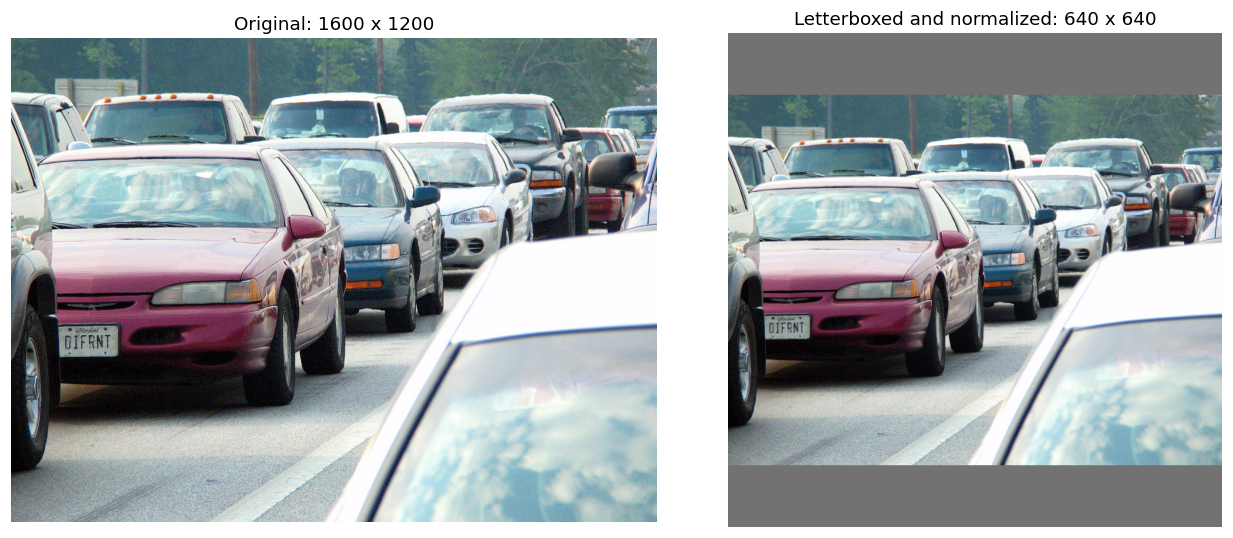

In [3]:
def letterbox(image, size=640):
    height, width = image.shape[:2]
    scale = min(size / width, size / height)
    new_width = max(1, min(size, round(width * scale)))
    new_height = max(1, min(size, round(height * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(image, (new_width, new_height), interpolation=interpolation)
    left = (size - new_width) // 2
    top = (size - new_height) // 2
    return cv2.copyMakeBorder(resized, top, size - new_height - top,
                              left, size - new_width - left,
                              cv2.BORDER_CONSTANT, value=(114, 114, 114))

traffic = load_image("traffic_scene.jpg", 1)
if traffic is not None:
    prepared = cv2.cvtColor(letterbox(traffic), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    stats = {"shape": list(prepared.shape), "min": float(prepared.min()),
             "max": float(prepared.max()), "dtype": str(prepared.dtype)}
    print("Preprocessed pixel tensor statistics:")
    print(json.dumps(stats, indent=2))
    output_path(1, "pixel_statistics.json").write_text(json.dumps(stats, indent=2), encoding="utf-8")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(traffic, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original: {traffic.shape[1]} x {traffic.shape[0]}")
    axes[1].imshow(prepared)
    axes[1].set_title("Letterboxed and normalized: 640 x 640")
    for axis in axes:
        axis.axis("off")
    fig.tight_layout()
    save_figure(1, "preprocessing.png", fig)
    STATUS[1] = "Executed"

## Task 2 — Industrial Defect Detection
Isolate **red marks as candidate defects** on a product. Color alone cannot prove a manufacturing defect. OpenCV hue uses 0–179, so red wraps around zero and requires two intervals. Tune the bounds for the supplied product and lighting. HSV and LAB channels are shown as scalar maps rather than incorrectly treating them as RGB images. Thresholding explicitly binarizes the combined mask; a small morphological opening removes isolated pixels.

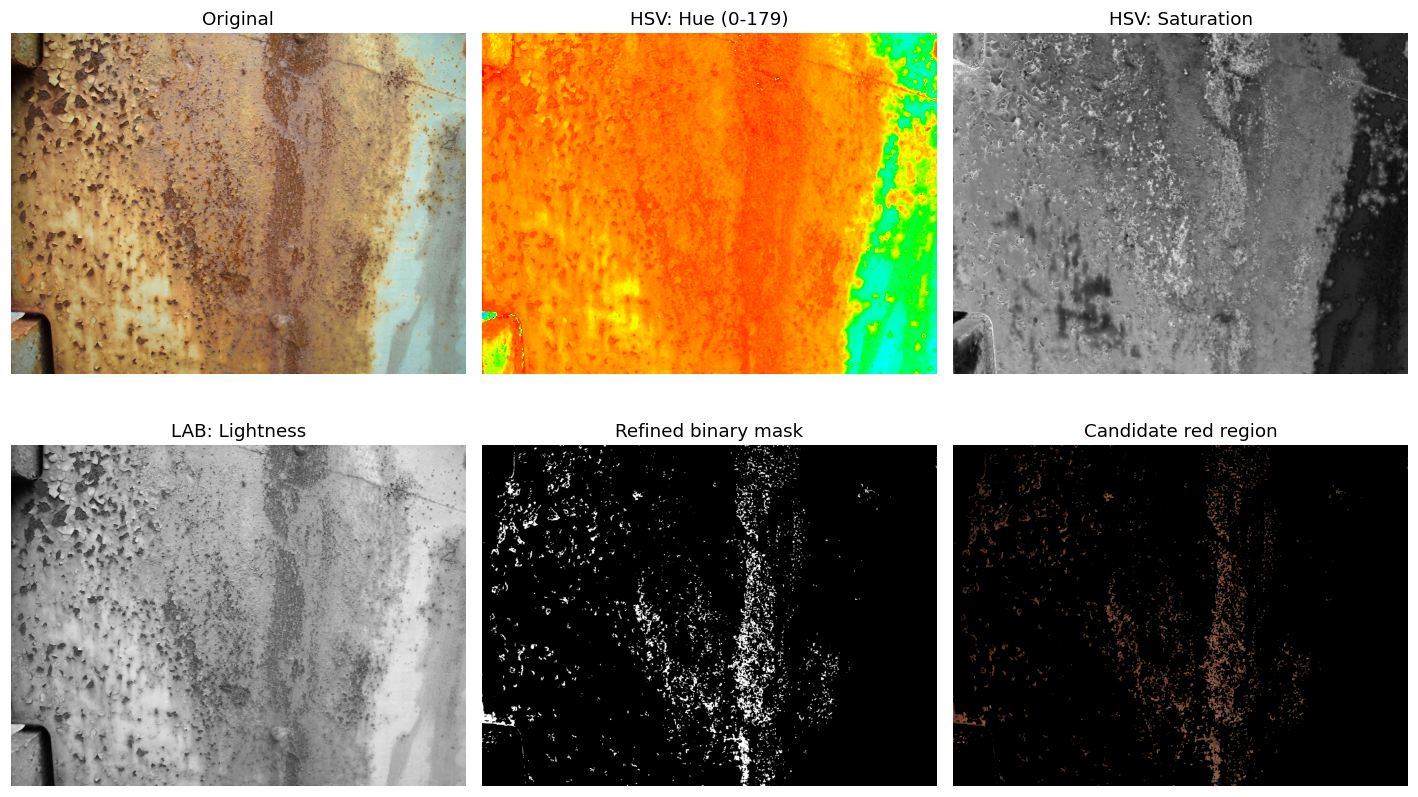

Candidate region pixels: 354499


In [4]:
product = load_image("industrial_product.jpg", 2)
if product is not None:
    hsv = cv2.cvtColor(product, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(product, cv2.COLOR_BGR2LAB)
    lower_red_1, upper_red_1 = np.array([0, 100, 60]), np.array([10, 255, 255])
    lower_red_2, upper_red_2 = np.array([170, 100, 60]), np.array([179, 255, 255])
    mask = cv2.bitwise_or(cv2.inRange(hsv, lower_red_1, upper_red_1),
                          cv2.inRange(hsv, lower_red_2, upper_red_2))
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    isolated = cv2.bitwise_and(product, product, mask=mask)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    panels = [(cv2.cvtColor(product, cv2.COLOR_BGR2RGB), "Original", None),
              (hsv[:, :, 0], "HSV: Hue (0-179)", "hsv"),
              (hsv[:, :, 1], "HSV: Saturation", "gray"),
              (lab[:, :, 0], "LAB: Lightness", "gray"),
              (mask, "Refined binary mask", "gray"),
              (cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB), "Candidate red region", None)]
    for axis, (pixels, title, cmap) in zip(axes.flat, panels):
        axis.imshow(pixels, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")
    fig.tight_layout()
    save_figure(2, "defect_grid.png", fig)
    save_image(2, "defect_mask.png", mask)
    save_image(2, "isolated_region.png", isolated)
    print(f"Candidate region pixels: {np.count_nonzero(mask)}")
    STATUS[2] = "Executed"

## Task 3 — Edge Detection & Noise Reduction
**Application: Medical Image Segmentation.** Compare 5 × 5 Gaussian and median smoothing before Sobel and Canny analysis. On this low-contrast X-ray, the initial 50/150 Canny thresholds suppressed most internal edges. Visual comparison of 10/30, 20/60, and 30/90 selected **10/30** to retain more anatomical detail. Both filters use the same thresholds for a fair comparison. This is visual parameter tuning, not validation against a reference segmentation.

Sobel and magnitude plots clip their display range at each map's 99th percentile so the scale marker and strong borders do not hide weaker edges. This changes only visualization brightness; quantitative means use the full, unclipped gradients. Edge counts and mean gradient magnitude measure map differences, not diagnostic quality.

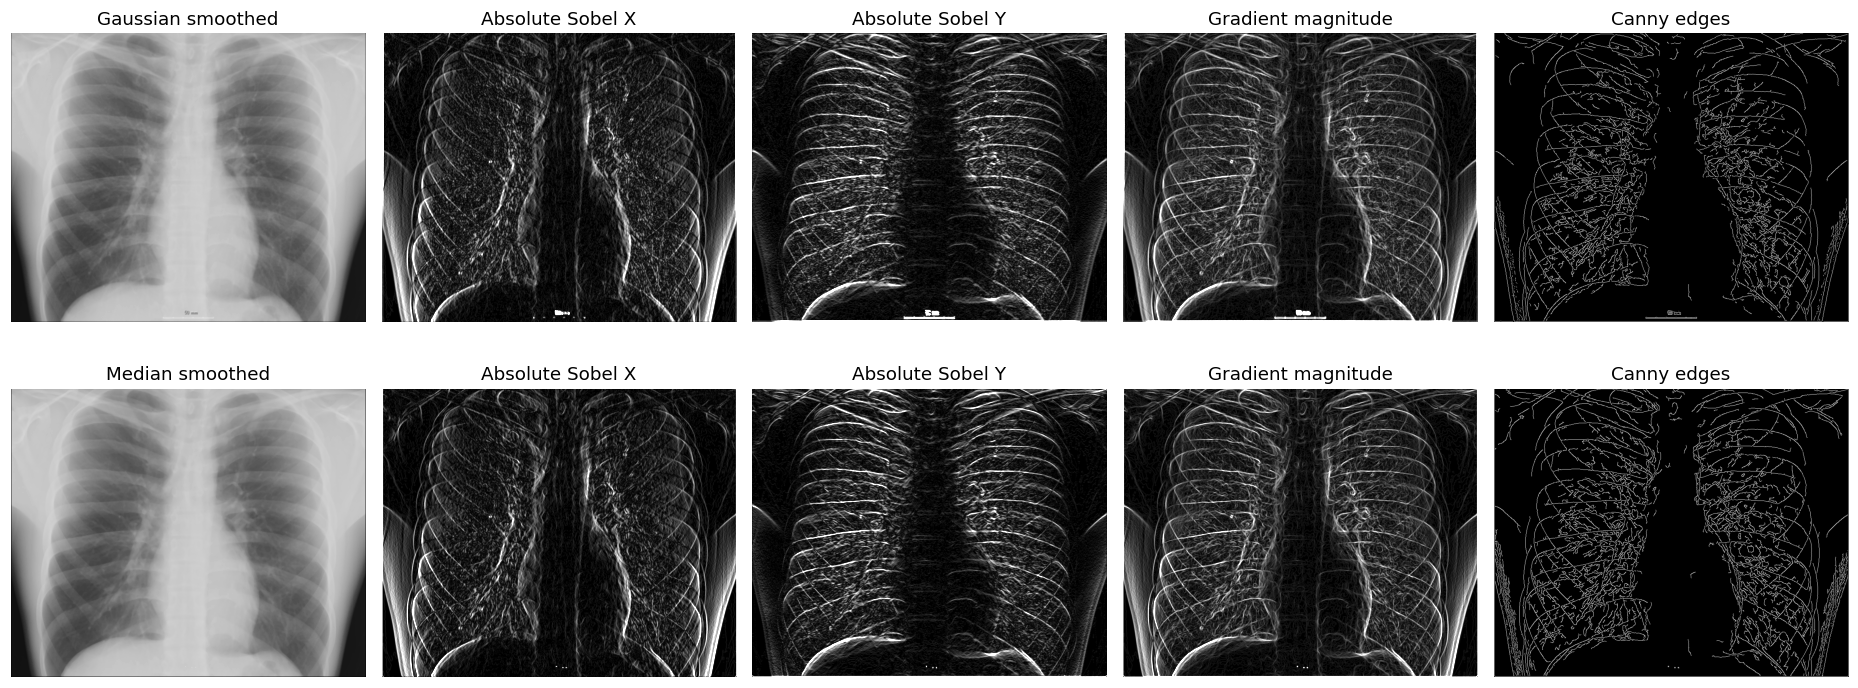

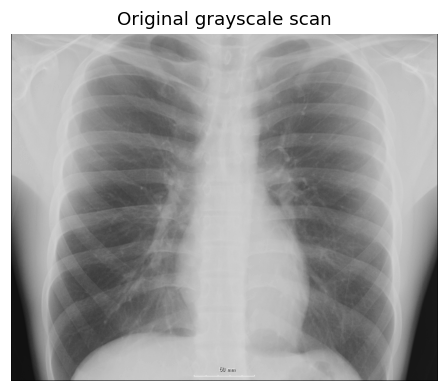

| Filter | Edge pixels | Mean gradient | Canny low | Canny high |
| --- | --- | --- | --- | --- |
| Gaussian | 43093 | 11.527 | 10 | 30 |
| Median | 50365 | 11.465 | 10 | 30 |

In [5]:
CANNY_LOW, CANNY_HIGH = 10, 30  # Tuned visually for the supplied low-contrast X-ray.
scan = load_image("medical_scan.png", 3, grayscale=True)
if scan is not None:
    filters = {"Gaussian": cv2.GaussianBlur(scan, (5, 5), 0),
               "Median": cv2.medianBlur(scan, 5)}
    metrics = []
    fig, axes = plt.subplots(2, 5, figsize=(17, 7))
    for row, (name, filtered) in enumerate(filters.items()):
        sobel_x = cv2.Sobel(filtered, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(filtered, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobel_x, sobel_y)
        edges = cv2.Canny(filtered, CANNY_LOW, CANNY_HIGH)
        metrics.append({"Filter": name, "Edge pixels": int(np.count_nonzero(edges)),
                        "Mean gradient": round(float(magnitude.mean()), 3),
                        "Canny low": CANNY_LOW, "Canny high": CANNY_HIGH})
        panels = [(filtered, name + " smoothed"), (np.abs(sobel_x), "Absolute Sobel X"),
                  (np.abs(sobel_y), "Absolute Sobel Y"), (magnitude, "Gradient magnitude"),
                  (edges, "Canny edges")]
        for axis, (pixels, title) in zip(axes[row], panels):
            display_max = max(1.0, float(np.percentile(pixels, 99))) if "Sobel" in title or "magnitude" in title else 255
            axis.imshow(pixels, cmap="gray", vmin=0, vmax=display_max)
            axis.set_title(title)
            axis.axis("off")
        save_image(3, name.lower() + "_edges.png", edges)
    fig.tight_layout()
    save_figure(3, "filter_comparison.png", fig)
    fig, axis = plt.subplots(figsize=(5, 5))
    axis.imshow(scan, cmap="gray")
    axis.set_title("Original grayscale scan")
    axis.axis("off")
    save_figure(3, "original_scan.png", fig)
    show_table(metrics)
    save_csv(3, "edge_metrics.csv", metrics)
    STATUS[3] = "Executed"

## Task 4 — Multi-Model YOLO Benchmark
Compare COCO-pretrained YOLOv8n and YOLOv8m on the same traffic image using CPU, image size 640, confidence threshold 0.25, and IoU threshold 0.45. Each model receives one untimed warm-up and three measured runs. Report mean prediction-call latency (preprocessing, inference, and post-processing) and mean model-only inference time reported by Ultralytics. Downloads, model loading, warm-up, and manual drawing are excluded. Counts and boxes come from the final run. Confidence and object count are descriptive results, not accuracy measurements.

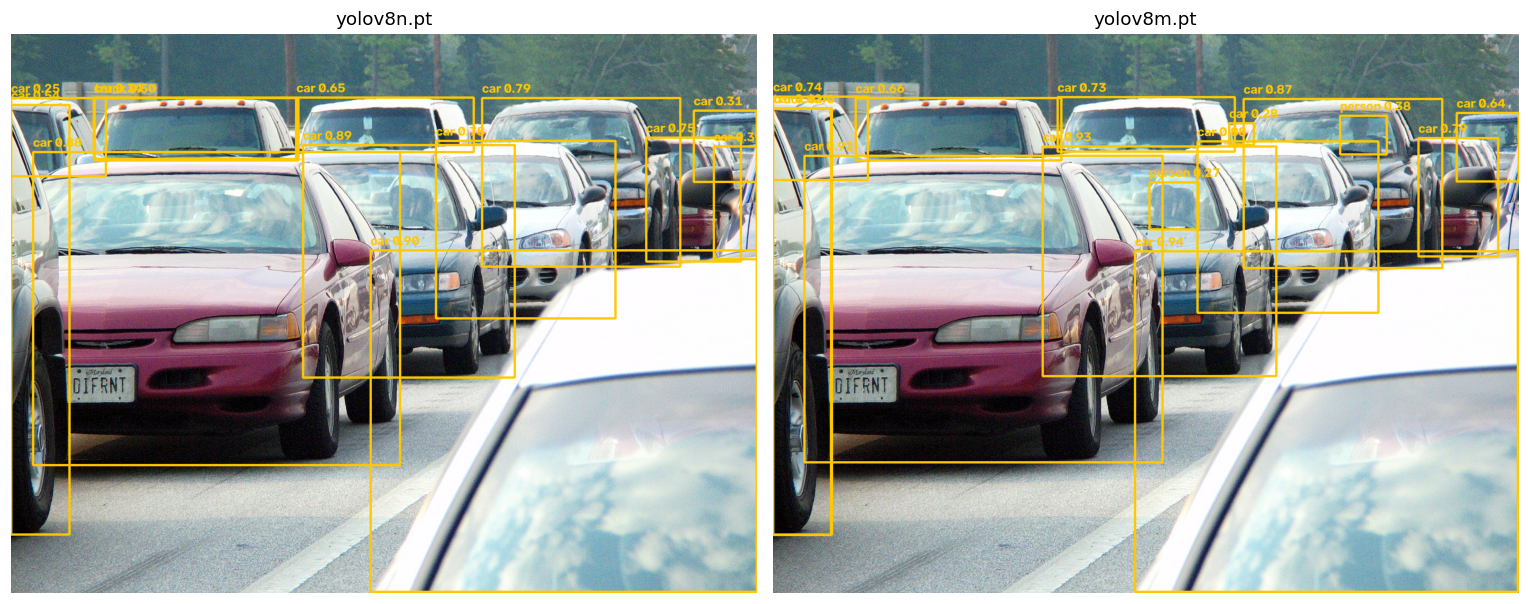

| Model | Mean prediction ms | Mean inference ms | Object count | Class counts | Average confidence |
| --- | --- | --- | --- | --- | --- |
| yolov8n.pt | 38.47 | 30.96 | 13 | {"car": 12, "truck": 1} | 0.6121 |
| yolov8m.pt | 165.42 | 162.03 | 15 | {"car": 12, "truck": 1, "person": 2} | 0.6694 |

In [6]:
benchmark_image = load_image("traffic_scene.jpg", 4)
if benchmark_image is not None:
    summaries, illustrations, all_detections = [], [], {}
    for name in ("yolov8n.pt", "yolov8m.pt"):
        model = get_model(name)
        options = dict(imgsz=640, conf=0.25, iou=0.45, device=DEVICE, verbose=False)
        model.predict(benchmark_image, **options)  # Warm up before timing.
        elapsed, inference_times = [], []
        for repeat in range(3):
            started = perf_counter()
            result = model.predict(benchmark_image, **options)[0]
            elapsed.append((perf_counter() - started) * 1000)
            inference_times.append(result.speed["inference"])
        detections = detections_from(result)
        counts = dict(Counter(item["label"] for item in detections))
        average = round(mean(item["confidence"] for item in detections), 4) if detections else "N/A"
        summaries.append({"Model": name, "Mean prediction ms": round(mean(elapsed), 2),
                          "Mean inference ms": round(mean(inference_times), 2),
                          "Object count": len(detections), "Class counts": json.dumps(counts),
                          "Average confidence": average})
        all_detections[name] = detections
        annotated = draw_boxes(benchmark_image, detections)
        illustrations.append((name, annotated))
        save_image(4, name.replace(".pt", "_detections.jpg"), annotated)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for axis, (name, annotated) in zip(axes, illustrations):
        axis.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axis.set_title(name)
        axis.axis("off")
    fig.tight_layout()
    save_figure(4, "model_comparison.png", fig)
    show_table(summaries)
    save_csv(4, "benchmark.csv", summaries)
    output_path(4, "detections.json").write_text(json.dumps(all_detections, indent=2), encoding="utf-8")
    STATUS[4] = "Executed"

## Task 5 — Retail Inventory Monitoring
Count bottles (COCO ID 39) with confidence strictly greater than 0.50. Set `TARGET_CLASS = "apple"` for COCO ID 47 if the shelf contains apples. A zero count is a valid model result and should not be replaced with an invented count. Occlusion and dense shelves may cause undercounting.

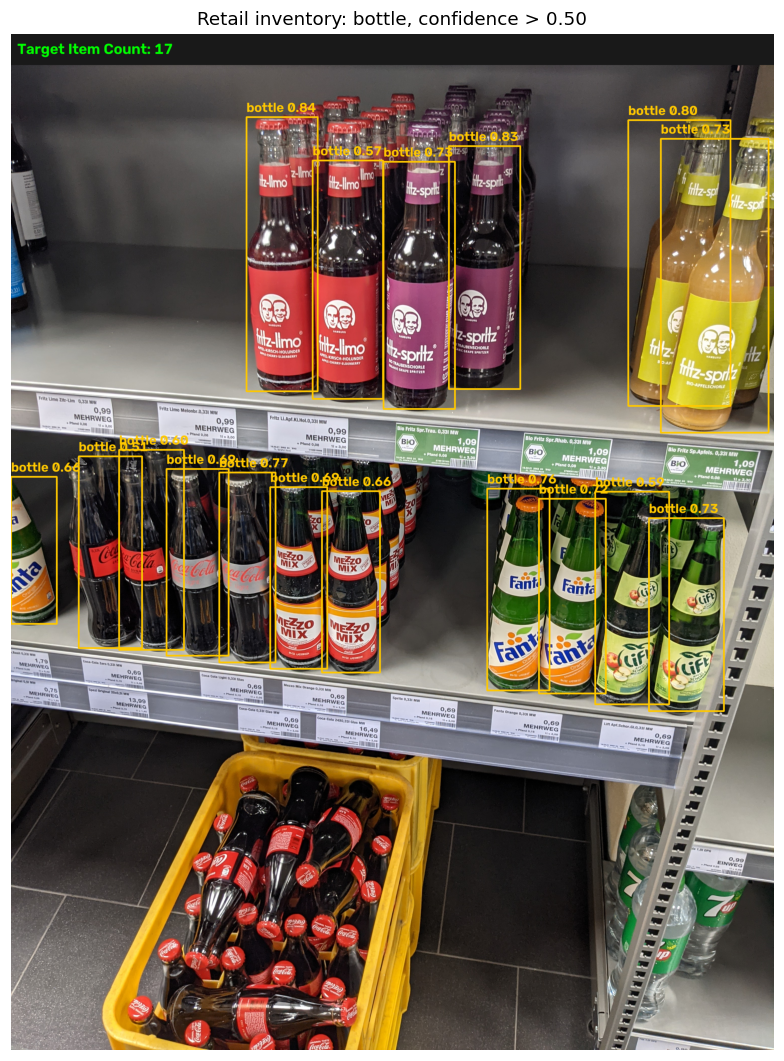

Target Item Count: 17


In [7]:
TARGET_CLASS = "bottle"
TARGET_ID = {"bottle": 39, "apple": 47}[TARGET_CLASS]
shelf = load_image("retail_shelf.jpg", 5)
if shelf is not None:
    result = get_model("yolov8n.pt").predict(shelf, imgsz=640, conf=0.50,
                                            classes=[TARGET_ID], device=DEVICE, verbose=False)[0]
    retained = [item for item in detections_from(result)
                if item["class_id"] == TARGET_ID and item["confidence"] > 0.50]
    annotated = banner(draw_boxes(shelf, retained), f"Target Item Count: {len(retained)}")
    fig, axis = plt.subplots(figsize=(9, 12))
    axis.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axis.set_title(f"Retail inventory: {TARGET_CLASS}, confidence > 0.50")
    axis.axis("off")
    save_figure(5, "inventory_figure.png", fig)
    save_image(5, "inventory_count.jpg", annotated)
    summary = {"target": TARGET_CLASS, "class_id": TARGET_ID, "count": len(retained), "detections": retained}
    output_path(5, "inventory.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    print(f"Target Item Count: {len(retained)}")
    STATUS[5] = "Executed"

## Task 6 — Smart Security Intrusion ROI
Define a four-point restricted polygon using fractional image coordinates, then convert it to OpenCV pixel coordinates. Edit the polygon to match the supplied scene. A person is inside when the box centroid is inside **or on the boundary** (`pointPolygonTest >= 0`). The ROI is red if any retained person is inside and green otherwise. Boxes and centroids are drawn for every detected person.

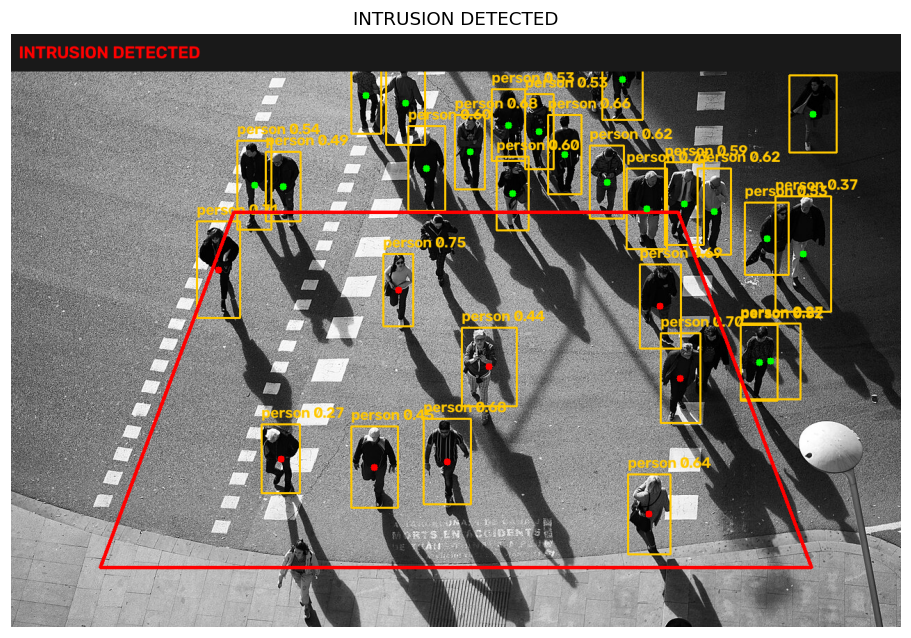

INTRUSION DETECTED


In [8]:
ROI_FRACTIONS = np.array([[0.25, 0.30], [0.75, 0.30], [0.90, 0.90], [0.10, 0.90]])
security = load_image("surveillance_scene.jpg", 6)
if security is not None:
    height, width = security.shape[:2]
    roi = np.round(ROI_FRACTIONS * [width - 1, height - 1]).astype(np.int32)
    result = get_model("yolov8n.pt").predict(security, imgsz=640, conf=0.25,
                                            classes=[0], device=DEVICE, verbose=False)[0]
    persons = [item for item in detections_from(result) if item["class_id"] == 0]
    intrusion = False
    for person in persons:
        x1, y1, x2, y2 = person["box"]
        centroid = ((x1 + x2) / 2, (y1 + y2) / 2)
        person["centroid"] = list(centroid)
        person["inside_roi"] = cv2.pointPolygonTest(roi, centroid, False) >= 0
        intrusion = intrusion or person["inside_roi"]
    color = (0, 0, 255) if intrusion else (0, 255, 0)
    message = "INTRUSION DETECTED" if intrusion else "SAFE: NO INTRUSION DETECTED"
    annotated = draw_boxes(security, persons)
    cv2.polylines(annotated, [roi], isClosed=True, color=color, thickness=max(3, round(width / 400)))
    for person in persons:
        center = tuple(map(int, person["centroid"]))
        cv2.circle(annotated, center, max(5, round(width / 240)), (0, 0, 255) if person["inside_roi"] else (0, 255, 0), -1)
    annotated = banner(annotated, message, color)
    save_image(6, "intrusion_result.jpg", annotated)
    output_path(6, "intrusion.json").write_text(json.dumps({"intrusion": intrusion,
        "roi": roi.tolist(), "persons": persons}, indent=2), encoding="utf-8")
    fig, axis = plt.subplots(figsize=(12, 7))
    axis.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axis.set_title(message)
    axis.axis("off")
    save_figure(6, "intrusion_figure.png", fig)
    print(message)
    STATUS[6] = "Executed"

## Task 7 — Real-Time Webcam Detection
Implemented in [`../src/live_detection.py`](../src/live_detection.py). Run from a PowerShell terminal at the repository root:

```powershell
.\aipdd_env\Scripts\python.exe .\src\live_detection.py
```

The script opens webcam 0, performs YOLO inference, draws boxes and processing FPS at the top-left, and releases the camera/windows on exit. FPS includes capture, inference, and drawing; GUI wait time is excluded. Press **q** to exit or **s** to save the displayed frame under `outputs/lab03/webcam/`. The directory is created on the first save. Webcam execution is manual and is not performed by this notebook.

## Task 8 — Edge-Triggered Webcam Surveillance
Implemented in [`../src/edge_triggered_surveillance.py`](../src/edge_triggered_surveillance.py).

```powershell
.\aipdd_env\Scripts\python.exe .\src\edge_triggered_surveillance.py --target person --cooldown 5
# Alternative high-priority class:
.\aipdd_env\Scripts\python.exe .\src\edge_triggered_surveillance.py --target "cell phone" --cooldown 5
```

A target confidence strictly greater than 0.65 triggers a snapshot and a JSON-line event. Each event records the timezone-aware timestamp, class, confidence, bounding box, and snapshot path. Snapshots use `outputs/lab03/alerts/YYYYMMDD_HHMMSS.jpg`; events append to `outputs/lab03/events.log`. The strongest target is logged once per cooldown period, and an on-screen indicator shows alert/logging state. This is a simple cooldown trigger: a continuously present target may produce another event after the cooldown. Press **q** to exit. No snapshots or events are generated until the script is actually run with a working camera.

The existing `.gitignore` excludes `*.log` and model weights. Logs remain available locally for submission; no ignore rules are changed by this lab.

## Execution Summary
The following table reports image-task execution in this run. Missing-image messages are not completed image-processing results. After adding inputs, run all cells again and save the notebook to preserve figures and tables inline. Outputs are also saved under the corresponding `outputs/lab03/taskN/` folder. When inputs or settings change, rerun the relevant task to refresh its saved results.

In [9]:
show_table([{"Task": number, "Status": STATUS.get(number, "Not run")} for number in range(1, 7)])
print("Task 7: manual webcam execution required (src/live_detection.py).")
print("Task 8: manual webcam execution required (src/edge_triggered_surveillance.py).")

| Task | Status |
| --- | --- |
| 1 | Executed |
| 2 | Executed |
| 3 | Executed |
| 4 | Executed |
| 5 | Executed |
| 6 | Executed |

Task 7: manual webcam execution required (src/live_detection.py).
Task 8: manual webcam execution required (src/edge_triggered_surveillance.py).
